# Geo‑Insight Challenge — Need vs Requested Resources (2024–2026)

**Goal**: highlight “forgotten / underserved” crises by comparing **humanitarian need** (HPC HNO `In Need`) to **resources** (HRP `revisedRequirements` as a proxy).

**Notes (important)**
- `revisedRequirements` are **requested USD**, not confirmed disbursed funding. We treat them as a consistent proxy and call out this limitation.
- We focus on **single‑country** HRP plans to avoid mis‑attributing multi‑country regional budgets.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Optional styling (falls back gracefully if seaborn isn't available)
try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

DATA_DIR = Path("../data/geo_mismatch")
YEARS = [2024, 2025, 2026]


def read_hdx_csv(path: Path, usecols=None) -> pd.DataFrame:
    """Read HDX-exported CSVs used in this repo.

    These files include a 2nd 'schema' row starting with '#...'.
    Some files also include a UTF-8 BOM; `utf-8-sig` handles it.
    """

    return pd.read_csv(
        path,
        skiprows=[1],
        encoding="utf-8-sig",
        usecols=usecols,
        low_memory=False,
    )


def split_pipe_list(x):
    if pd.isna(x):
        return []
    return [p.strip() for p in str(x).split("|") if p.strip()]


def show(df: pd.DataFrame, n: int = 10):
    """Display a dataframe in Databricks/Jupyter; otherwise print a preview."""

    try:
        from IPython.display import display

        display(df.head(n))
    except Exception:
        print(df.head(n))


In [2]:
# Load datasets (only the columns we use)
HRP_COLS = [
    "code",
    "startDate",
    "endDate",
    "planVersion",
    "categories",
    "locations",
    "years",
    "origRequirements",
    "revisedRequirements",
]

HNO_COLS = [
    "Country ISO3",
    "Description",
    "Cluster",
    "Category",
    "Population",
    "In Need",
    "Targeted",
    "Affected",
    "Reached",
    "Info",
]

COD0_COLS = ["ISO3", "Country", "Population_group", "Gender", "Age_range"]

hrp = read_hdx_csv(DATA_DIR / "humanitarian-response-plans.csv", usecols=HRP_COLS)

hno = pd.concat(
    [
        read_hdx_csv(DATA_DIR / f"hpc_hno_{y}.csv", usecols=HNO_COLS).assign(year=y)
        for y in YEARS
    ],
    ignore_index=True,
    sort=False,
)

cod0 = read_hdx_csv(DATA_DIR / "cod_population_admin0.csv", usecols=COD0_COLS)

# Numeric cleanup
for c in ["origRequirements", "revisedRequirements"]:
    hrp[c] = pd.to_numeric(hrp[c], errors="coerce")

for c in ["Population", "In Need", "Targeted", "Affected", "Reached"]:
    hno[c] = pd.to_numeric(hno[c], errors="coerce")

print("HRP rows:", len(hrp), "| HNO rows:", len(hno), "| COD admin0 rows:", len(cod0))
print("HNO years present:", sorted(hno["year"].unique().tolist()))

# ISO3 -> country name map (best effort)
name_map = (
    cod0.query("Population_group == 'T_TL' and Gender == 'all' and Age_range == 'all'")
    [["ISO3", "Country"]]
    .drop_duplicates("ISO3")
)

# Fill gaps where COD doesn't include a country
manual_name_map = {
    "MMR": "Myanmar",
    "CAF": "Central African Republic",
    "YEM": "Yemen",
    "SYR": "Syria",
}


HRP rows: 910 | HNO rows: 706159 | COD admin0 rows: 6722
HNO years present: [2024, 2025, 2026]


## Build the country‑year table (need vs requested resources)

We use **HNO overall caseload** rows (Cluster `ALL` + blank Category) as the “need” baseline, and **single‑country HRP plans** as the “resources” proxy.

In [3]:
# 1) HNO: extract “overall caseload” rows (Cluster=ALL, Category blank)
hno_clean = hno.copy()
hno_clean["Cluster"] = hno_clean["Cluster"].astype(str).str.strip()
hno_clean["Category"] = hno_clean["Category"].fillna("").astype(str).str.strip()

hno_overall = (
    hno_clean.query("Cluster == 'ALL' and Category == ''")
    .rename(
        columns={
            "Country ISO3": "iso3",
            "Population": "population",
            "In Need": "in_need",
            "Targeted": "targeted",
            "Affected": "affected",
            "Reached": "reached",
        }
    )
    [[
        "year",
        "iso3",
        "Description",
        "population",
        "in_need",
        "targeted",
        "affected",
        "reached",
    ]]
    .copy()
)

# Validate uniqueness
_dups = hno_overall.duplicated(["year", "iso3"], keep=False)
print("HNO overall rows:", len(hno_overall))
print(
    "HNO overall uniqueness OK?",
    "YES" if not _dups.any() else f"NO ({_dups.sum()} duplicate rows)",
)

show(
    hno_overall.groupby("year").agg(rows=("iso3", "size"), countries=("iso3", "nunique")).reset_index(),
    n=10,
)

if _dups.any():
    show(hno_overall.loc[_dups].sort_values(["year", "iso3"]).head(25), n=25)

# 2) HRP: parse locations/years, then keep single-country plans
hrp_parsed = hrp.copy()
hrp_parsed["loc_list"] = hrp_parsed["locations"].apply(split_pipe_list)
hrp_parsed["year_list"] = hrp_parsed["years"].apply(split_pipe_list)
hrp_parsed["n_locations"] = hrp_parsed["loc_list"].map(len)
hrp_parsed["n_years"] = hrp_parsed["year_list"].map(len)

print("\nHRP plan count by number of locations (top):")
show(hrp_parsed["n_locations"].value_counts().rename_axis("n_locations").reset_index(name="n_plans").head(12))

hrp_single = hrp_parsed.query("n_locations == 1").copy()
hrp_single = hrp_single.explode("year_list")
hrp_single["year"] = pd.to_numeric(hrp_single["year_list"], errors="coerce")
hrp_single = hrp_single[hrp_single["year"].isin(YEARS)].copy()
hrp_single["year"] = hrp_single["year"].astype(int)
hrp_single["iso3"] = hrp_single["loc_list"].str[0]

# Aggregate resources proxy at country-year
hrp_country_year = (
    hrp_single.assign(revisedRequirements=hrp_single["revisedRequirements"].fillna(0))
    .groupby(["year", "iso3"], as_index=False)
    .agg(
        req_sum=("revisedRequirements", "sum"),
        req_max=("revisedRequirements", "max"),
        n_plans=("code", "nunique"),
    )
)

multi = hrp_country_year.query("n_plans > 1").sort_values(["year", "n_plans"], ascending=[True, False])
print("\nCountry-years with >1 single-country HRP plan:", len(multi))
if len(multi):
    show(multi.head(15), n=15)

# 3) Coverage: HNO overall should be covered by single-country HRP for these years
coverage = hno_overall[["year", "iso3"]].merge(
    hrp_country_year[["year", "iso3"]],
    on=["year", "iso3"],
    how="left",
    indicator=True,
)
print("\nCoverage (HNO overall → HRP single-country):")
show(coverage["_merge"].value_counts().rename_axis("merge_status").reset_index(name="n"), n=10)

missing = coverage.query("_merge != 'both'")
if len(missing):
    print("Missing HRP rows (showing up to 25):")
    show(missing.head(25), n=25)


HNO overall rows: 66
HNO overall uniqueness OK? YES


,year,rows,countries
0,2024,24,24
1,2025,22,22
2,2026,20,20



HRP plan count by number of locations (top):


,n_locations,n_plans
0,1,811
1,0,23
2,5,18
3,3,14
4,4,8
5,17,7
6,6,5
7,7,5
8,2,4
9,9,4



Country-years with >1 single-country HRP plan: 7


,year,iso3,req_sum,req_max,n_plans
3,2024,BGD,951060075,852360782,2
19,2024,MOZ,502445224,413420177,2
30,2024,SYR,4209822792,4074158710,2
52,2025,MOZ,682722983,352096942,3
41,2025,BGD,970135849,934521017,2
51,2025,MMR,1412961603,1137811569,2
67,2025,VNM,72255405,37218750,2



Coverage (HNO overall → HRP single-country):


,merge_status,n
0,both,66
1,left_only,0
2,right_only,0


In [4]:
# 4) Build the core analytic table + metrics
core = (
    hno_overall.merge(hrp_country_year, on=["year", "iso3"], how="left")
    .merge(name_map.rename(columns={"ISO3": "iso3", "Country": "country"}), on="iso3", how="left")
)

# Fill country names where COD mapping is missing
core["country"] = core["country"].fillna(core["iso3"].map(manual_name_map)).fillna(core["iso3"])

# Fill missing req fields (should be rare if coverage is good)
for c in ["req_sum", "req_max", "n_plans"]:
    if c in core.columns:
        core[c] = core[c].fillna(0)

# Derived metrics
core["need_rate"] = core["in_need"] / core["population"]
core["usd_per_in_need"] = core["req_sum"] / core["in_need"]
core["usd_per_in_need_max"] = core["req_max"] / core["in_need"]
core["req_per_capita"] = core["req_sum"] / core["population"]

# Share gap within year ("forgotten" signal)
core["need_share"] = core.groupby("year")["in_need"].transform(lambda s: s / s.sum())
core["req_share"] = core.groupby("year")["req_sum"].transform(lambda s: s / s.sum())
core["share_gap"] = core["need_share"] - core["req_share"]

# Percentile-based mismatch (robust + interpretable)
core["need_pct"] = core.groupby("year")["need_rate"].rank(pct=True, method="average")
core["usd_pct"] = core.groupby("year")["usd_per_in_need"].rank(pct=True, method="average")
core["usd_pct_max"] = core.groupby("year")["usd_per_in_need_max"].rank(pct=True, method="average")

core["mismatch"] = core["need_pct"] - core["usd_pct"]
core["mismatch_max"] = core["need_pct"] - core["usd_pct_max"]

# Clean view for reporting
report_cols = [
    "year",
    "iso3",
    "country",
    "population",
    "in_need",
    "need_rate",
    "req_sum",
    "usd_per_in_need",
    "share_gap",
    "mismatch",
    "n_plans",
]

latest = max(YEARS)

print("Core table rows:", len(core), "| years:", sorted(core["year"].unique().tolist()))

show(
    core.loc[core["year"] == latest, report_cols]
    .sort_values("mismatch", ascending=False)
    .head(12),
    n=12,
)

# Top underserved per year (compact)
for y in YEARS:
    top = (
        core.loc[core["year"] == y, report_cols]
        .sort_values("mismatch", ascending=False)
        .head(10)
        .copy()
    )
    top["need_rate"] = (top["need_rate"] * 100).round(1)
    top["usd_per_in_need"] = top["usd_per_in_need"].round(0)
    top["share_gap"] = (top["share_gap"] * 100).round(2)
    top["mismatch"] = top["mismatch"].round(3)

    print(f"\nTop underserved (proxy) — {y}")
    show(
        top.rename(
            columns={
                "need_rate": "need_rate_%",
                "usd_per_in_need": "usd_per_in_need_$",
                "share_gap": "share_gap_%pts",
            }
        ),
        n=10,
    )


Core table rows: 66 | years: [2024, 2025, 2026]


,year,iso3,country,population,in_need,need_rate,req_sum,usd_per_in_need,share_gap,mismatch,n_plans
58,2026,SDN,Sudan,51700000.0,33700000.0,0.651838,2866228594,85.051294,0.042775,0.70,1
46,2026,AFG,Afghanistan,48595632.0,21889283.0,0.450437,1714181496,78.311450,0.034173,0.55,1
54,2026,MMR,Myanmar,54900000.0,16229050.0,0.295611,889600798,54.815334,0.041850,0.55,1
64,2026,VEN,Venezuela (Bolivarian Republic of),28500000.0,7900000.0,0.277193,606000000,76.708861,0.012881,0.40,1
65,2026,YEM,Yemen,41800000.0,23100000.0,0.552632,2470000000,106.926407,0.007436,0.40,1
60,2026,SSD,South Sudan,14363363.0,9913863.0,0.690219,1463046056,147.575779,-0.014261,0.35,1
52,2026,HTI,Haiti,11899555.0,6414193.0,0.539028,880327426,137.246794,-0.006358,0.20,1
51,2026,COL,Colombia,53400000.0,6900000.0,0.129213,384000000,55.652174,0.017543,0.15,1
48,2026,CAF,Central African Republic,6567382.0,2286959.0,0.348230,264097388,115.479721,-0.000111,0.15,1
61,2026,SYR,Syria,25600000.0,16500000.0,0.644531,3190000000,193.333333,-0.056433,0.05,1



Top underserved (proxy) — 2024


,year,iso3,country,population,in_need,need_rate_%,req_sum,usd_per_in_need_$,share_gap_%pts,mismatch,n_plans
15,2024,SDN,Sudan,50990034.0,24786370.0,48.6,2695680744,109.0,1.89,0.500,1
11,2024,MMR,Myanmar,56586109.0,18590021.0,32.9,993548103,53.0,4.48,0.500,1
7,2024,GTM,Guatemala,17600000.0,5300000.0,30.1,125401425,24.0,1.75,0.458,1
0,2024,AFG,Afghanistan,44532600.0,23666389.0,53.1,3059587797,129.0,0.36,0.375,1
9,2024,HTI,Haiti,11700000.0,5500000.0,47.0,673767352,123.0,0.19,0.333,1
8,2024,HND,Honduras,9800000.0,2800000.0,28.6,203159869,73.0,0.52,0.292,1
10,2024,MLI,Mali,22411911.0,7107194.0,31.7,701569941,99.0,0.75,0.250,1
22,2024,VEN,Venezuela (Bolivarian Republic of),27225775.0,7581480.0,27.8,617034811,81.0,1.20,0.167,1
18,2024,SSD,South Sudan,12440000.0,8996986.0,72.3,1788817122,199.0,-1.73,0.167,1
2,2024,CAF,Central African Republic,6148956.0,2801810.0,45.6,367670976,131.0,0.03,0.167,1



Top underserved (proxy) — 2025


,year,iso3,country,population,in_need,need_rate_%,req_sum,usd_per_in_need_$,share_gap_%pts,mismatch,n_plans
24,2025,AFG,Afghanistan,46024352.0,22887726.0,49.7,2416811546,106.0,3.13,0.545,1
44,2025,VEN,Venezuela (Bolivarian Republic of),27112332.0,7943720.0,29.3,606497714,76.0,1.95,0.455,1
45,2025,YEM,Yemen,34879018.0,19540217.0,56.0,2478772922,127.0,1.12,0.409,1
29,2025,COL,Colombia,53110609.0,9053352.0,17.0,342308343,38.0,3.53,0.364,1
38,2025,SDN,Sudan,46790687.0,30440770.0,65.1,4162518656,137.0,0.63,0.318,1
41,2025,SSD,South Sudan,13442554.0,9290088.0,69.1,1694778653,182.0,-1.39,0.273,1
26,2025,CAF,Central African Republic,5296124.0,2440338.0,46.1,326056578,134.0,0.08,0.227,1
32,2025,HTI,Haiti,11899555.0,5986456.0,50.3,908159989,152.0,-0.21,0.182,1
30,2025,GTM,Guatemala,18400000.0,2163953.0,11.8,100563396,46.0,0.77,0.182,1
31,2025,HND,Honduras,10800000.0,1640224.0,15.2,138491372,84.0,0.35,0.136,1



Top underserved (proxy) — 2026


,year,iso3,country,population,in_need,need_rate_%,req_sum,usd_per_in_need_$,share_gap_%pts,mismatch,n_plans
58,2026,SDN,Sudan,51700000.0,33700000.0,65.2,2866228594,85.0,4.28,0.70,1
46,2026,AFG,Afghanistan,48595632.0,21889283.0,45.0,1714181496,78.0,3.42,0.55,1
54,2026,MMR,Myanmar,54900000.0,16229050.0,29.6,889600798,55.0,4.19,0.55,1
64,2026,VEN,Venezuela (Bolivarian Republic of),28500000.0,7900000.0,27.7,606000000,77.0,1.29,0.40,1
65,2026,YEM,Yemen,41800000.0,23100000.0,55.3,2470000000,107.0,0.74,0.40,1
60,2026,SSD,South Sudan,14363363.0,9913863.0,69.0,1463046056,148.0,-1.43,0.35,1
52,2026,HTI,Haiti,11899555.0,6414193.0,53.9,880327426,137.0,-0.64,0.20,1
51,2026,COL,Colombia,53400000.0,6900000.0,12.9,384000000,56.0,1.75,0.15,1
48,2026,CAF,Central African Republic,6567382.0,2286959.0,34.8,264097388,115.0,-0.01,0.15,1
61,2026,SYR,Syria,25600000.0,16500000.0,64.5,3190000000,193.0,-5.64,0.05,1


## Results (proxy): who looks underserved?

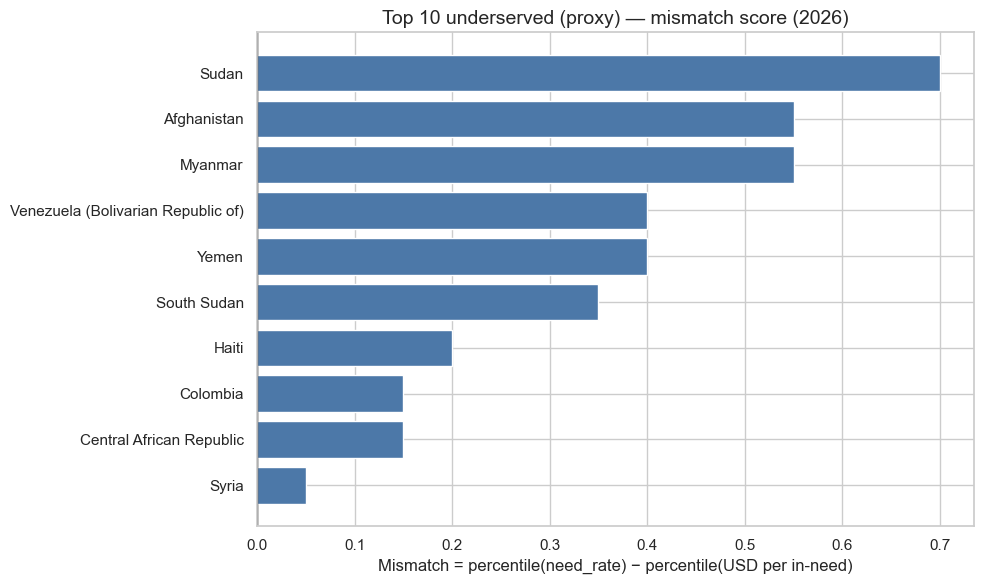

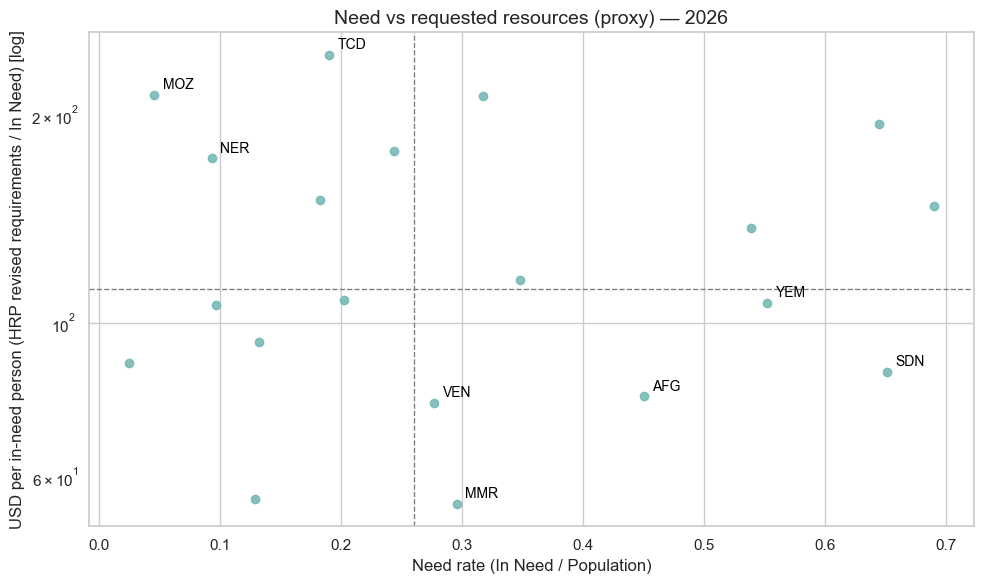

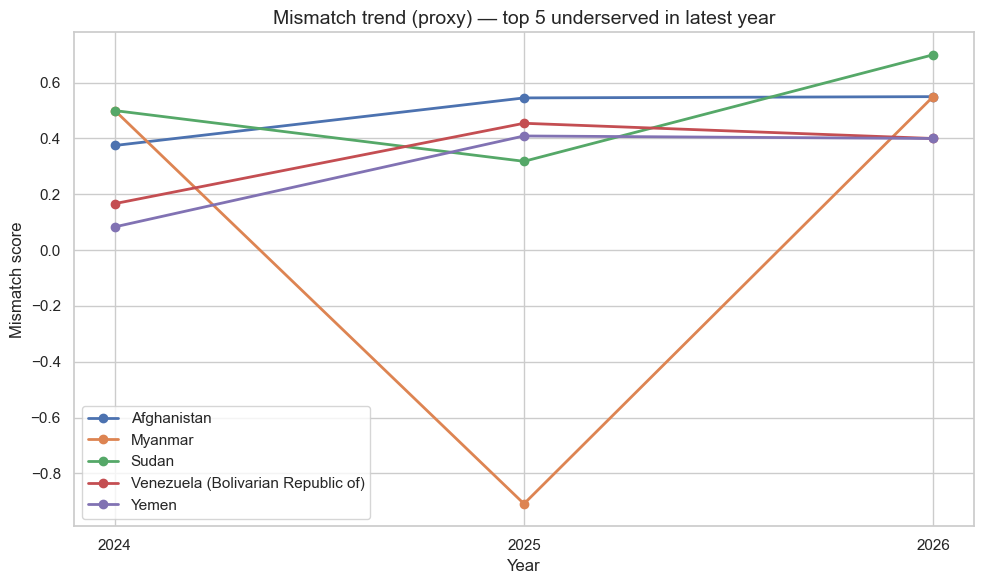

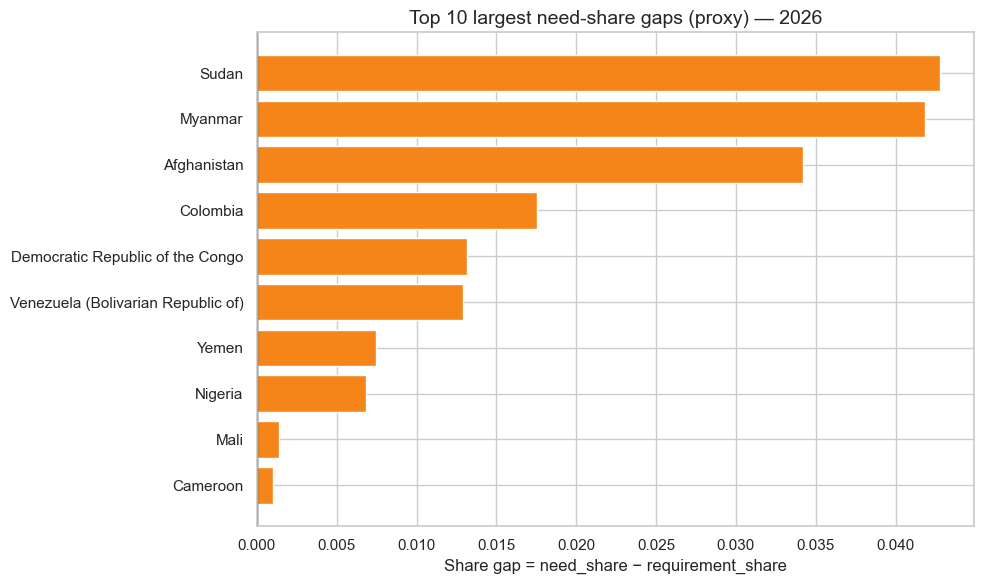

In [5]:
# Helper for consistent labels
core_plot = core.copy()
core_plot["need_rate_pct"] = core_plot["need_rate"] * 100

# 1) Ranked bar: top underserved (latest year)
y = latest
bar = (
    core_plot.loc[core_plot["year"] == y]
    .sort_values("mismatch", ascending=False)
    .head(10)
    .sort_values("mismatch", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(bar["country"], bar["mismatch"], color="#4C78A8")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top 10 underserved (proxy) — mismatch score ({y})")
plt.xlabel("Mismatch = percentile(need_rate) − percentile(USD per in-need)")
plt.tight_layout()
plt.show()

# 2) Scatter: need_rate vs USD per in-need (latest year)
sc = core_plot.loc[core_plot["year"] == y].copy()
sc = sc.replace([np.inf, -np.inf], np.nan).dropna(subset=["need_rate", "usd_per_in_need"])

# Log scale requires positive values
sc = sc.loc[sc["usd_per_in_need"] > 0].copy()

x_med = sc["need_rate"].median()
y_med = sc["usd_per_in_need"].median()

plt.figure(figsize=(10, 6))
plt.scatter(sc["need_rate"], sc["usd_per_in_need"], alpha=0.85, color="#72B7B2")
plt.axvline(x_med, color="gray", linestyle="--", linewidth=1)
plt.axhline(y_med, color="gray", linestyle="--", linewidth=1)
plt.yscale("log")
plt.title(f"Need vs requested resources (proxy) — {y}")
plt.xlabel("Need rate (In Need / Population)")
plt.ylabel("USD per in-need person (HRP revised requirements / In Need) [log]")

# Label a few key points: top 5 underserved + top 3 overserved
label_under = sc.sort_values("mismatch", ascending=False).head(5)
label_over = sc.sort_values("mismatch", ascending=True).head(3)
labels = pd.concat([label_under, label_over], ignore_index=True)
for _, r in labels.iterrows():
    plt.annotate(
        r["iso3"],
        (r["need_rate"], r["usd_per_in_need"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=10,
        color="black",
    )

plt.tight_layout()
plt.show()

# 3) Trend: mismatch over time for the latest-year top 5 underserved
focus_iso3 = (
    core_plot.loc[core_plot["year"] == latest]
    .sort_values("mismatch", ascending=False)
    .head(5)["iso3"]
    .tolist()
)
trend = core_plot.loc[core_plot["iso3"].isin(focus_iso3), ["year", "iso3", "country", "mismatch", "usd_per_in_need"]].copy()
trend = trend.sort_values(["country", "year"])

plt.figure(figsize=(10, 6))
for ctry, g in trend.groupby("country"):
    plt.plot(g["year"], g["mismatch"], marker="o", linewidth=2, label=ctry)

plt.title("Mismatch trend (proxy) — top 5 underserved in latest year")
plt.xlabel("Year")
plt.ylabel("Mismatch score")
plt.xticks(YEARS)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 4) Share-gap view (latest year): % of in-need minus % of requirements
sg = (
    core_plot.loc[core_plot["year"] == latest]
    .sort_values("share_gap", ascending=False)
    .head(10)
    .sort_values("share_gap", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(sg["country"], sg["share_gap"], color="#F58518")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top 10 largest need-share gaps (proxy) — {latest}")
plt.xlabel("Share gap = need_share − requirement_share")
plt.tight_layout()
plt.show()


## Optional: actual funding (FTS)

Best-effort enrichment using the **FTS public API** (`/v1/public/fts/flow`). If it fails (no internet / rate limits), this section will skip and the notebook still works.


Top underserved (FTS actual funding) — latest year


,year,iso3,country,in_need,need_rate_%,req_sum_usd,funded_usd,funded_per_in_need_$,funding_coverage_%,mismatch_funded
58,2026,SDN,Sudan,33700000.0,65.2,2866228594,191133269,6.0,6.7,0.65
52,2026,HTI,Haiti,6414193.0,53.9,880327426,30575121,5.0,3.5,0.60
65,2026,YEM,Yemen,23100000.0,55.3,2470000000,112052464,5.0,4.5,0.60
54,2026,MMR,Myanmar,16229050.0,29.6,889600798,62866796,4.0,7.1,0.50
64,2026,VEN,Venezuela (Bolivarian Republic of),7900000.0,27.7,606000000,23528403,3.0,3.9,0.50
61,2026,SYR,Syria,16500000.0,64.5,3190000000,129274838,8.0,4.1,0.40
46,2026,AFG,Afghanistan,21889283.0,45.0,1714181496,163563703,7.0,9.5,0.30
60,2026,SSD,South Sudan,9913863.0,69.0,1463046056,150765790,15.0,10.3,0.15
51,2026,COL,Colombia,6900000.0,12.9,384000000,32492306,5.0,8.5,0.10
48,2026,CAF,Central African Republic,2286959.0,34.8,264097388,23237231,10.0,8.8,0.00



Top underserved (FTS) — 2024


,year,iso3,country,in_need,need_rate_%,req_sum_usd,funded_usd,funded_per_in_need_$,funding_coverage_%,mismatch_funded
11,2024,MMR,Myanmar,18590021.0,32.9,993548103,457855704,25.0,46.1,0.542
7,2024,GTM,Guatemala,5300000.0,30.1,125401425,85709007,16.0,68.3,0.458
0,2024,AFG,Afghanistan,23666389.0,53.1,3059587797,1696053535,72.0,55.4,0.417
9,2024,HTI,Haiti,5500000.0,47.0,673767352,366206643,67.0,54.4,0.375
22,2024,VEN,Venezuela (Bolivarian Republic of),7581480.0,27.8,617034811,202252762,27.0,32.8,0.292
10,2024,MLI,Mali,7107194.0,31.7,701569941,347088323,49.0,49.5,0.292
15,2024,SDN,Sudan,24786370.0,48.6,2695680744,2059813993,83.0,76.4,0.250



Top underserved (FTS) — 2025


,year,iso3,country,in_need,need_rate_%,req_sum_usd,funded_usd,funded_per_in_need_$,funding_coverage_%,mismatch_funded
44,2025,VEN,Venezuela (Bolivarian Republic of),7943720.0,29.3,606497714,120724933,15.0,19.9,0.545
32,2025,HTI,Haiti,5986456.0,50.3,908159989,272295851,45.0,30.0,0.409
38,2025,SDN,Sudan,30440770.0,65.1,4162518656,1707542398,56.0,41.0,0.364
24,2025,AFG,Afghanistan,22887726.0,49.7,2416811546,1127733216,49.0,46.7,0.318
31,2025,HND,Honduras,1640224.0,15.2,138491372,27263290,17.0,19.7,0.273
33,2025,MLI,Mali,6431534.0,27.8,771314315,208301746,32.0,27.0,0.273
29,2025,COL,Colombia,9053352.0,17.0,342308343,203966878,23.0,59.6,0.227



Top underserved (FTS) — 2026


,year,iso3,country,in_need,need_rate_%,req_sum_usd,funded_usd,funded_per_in_need_$,funding_coverage_%,mismatch_funded
58,2026,SDN,Sudan,33700000.0,65.2,2866228594,191133269,6.0,6.7,0.65
52,2026,HTI,Haiti,6414193.0,53.9,880327426,30575121,5.0,3.5,0.60
65,2026,YEM,Yemen,23100000.0,55.3,2470000000,112052464,5.0,4.5,0.60
54,2026,MMR,Myanmar,16229050.0,29.6,889600798,62866796,4.0,7.1,0.50
64,2026,VEN,Venezuela (Bolivarian Republic of),7900000.0,27.7,606000000,23528403,3.0,3.9,0.50
61,2026,SYR,Syria,16500000.0,64.5,3190000000,129274838,8.0,4.1,0.40
46,2026,AFG,Afghanistan,21889283.0,45.0,1714181496,163563703,7.0,9.5,0.30


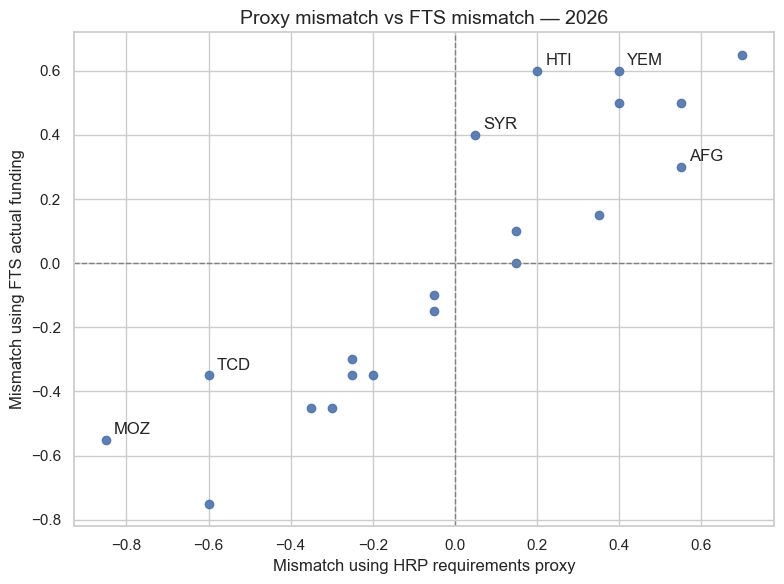

In [6]:
import json
from urllib.parse import urlencode
from urllib.request import Request, urlopen


def fetch_json(url: str, timeout: int = 20) -> dict:
    req = Request(url, headers={"User-Agent": "datathon-geo-insight"})
    with urlopen(req, timeout=timeout) as resp:
        return json.loads(resp.read().decode("utf-8"))


def fetch_fts_incoming_totals(country_iso3: str, year: int, timeout: int = 20) -> dict:
    """Fetch FTS incoming totals for a country-year boundary.

    Uses a small `limit` to keep payload small; totals are still provided.
    """

    base = "https://api.hpc.tools/v1/public/fts/flow"
    qs = urlencode({"countryISO3": country_iso3, "year": int(year), "limit": 1})
    url = f"{base}?{qs}"
    payload = fetch_json(url, timeout=timeout)

    if payload.get("status") != "ok":
        raise RuntimeError(f"FTS status not ok: {payload.get('status')}")

    data = payload.get("data") or {}
    incoming = data.get("incoming") or {}

    return {
        "fts_flow_count": incoming.get("flowCount"),
        "fts_funding_total_usd": incoming.get("fundingTotal"),
        "fts_pledge_total_usd": incoming.get("pledgeTotal"),
        "fts_url": url,
    }


# Pull actual funding totals for each country-year in our analysis set
funding_rows = []
errors = []

for (y, iso3) in (
    core[["year", "iso3"]].drop_duplicates().sort_values(["year", "iso3"]).itertuples(index=False)
):
    try:
        out = fetch_fts_incoming_totals(iso3, y, timeout=20)
        funding_rows.append({"year": int(y), "iso3": iso3, **out})
    except Exception as e:
        errors.append((int(y), iso3, str(e)))

funding_df = pd.DataFrame(funding_rows)

if len(errors):
    print(f"FTS fetch warnings: {len(errors)} failures (showing first 5)")
    for row in errors[:5]:
        print(" -", row)

if len(funding_df) == 0:
    print("\nFTS funding not available in this environment; skipping actual-funding analysis.")
else:
    core_f = core.merge(funding_df, on=["year", "iso3"], how="left")

    # Coerce numeric
    for c in ["fts_funding_total_usd", "fts_pledge_total_usd"]:
        core_f[c] = pd.to_numeric(core_f[c], errors="coerce")

    core_f["funded_usd"] = core_f["fts_funding_total_usd"]
    core_f["funded_per_in_need"] = core_f["funded_usd"] / core_f["in_need"]
    core_f["funding_coverage"] = core_f["funded_usd"] / core_f["req_sum"]

    # Percentile mismatch using actual funding
    core_f["funded_pct"] = core_f.groupby("year")["funded_per_in_need"].rank(
        pct=True, method="average"
    )
    core_f["mismatch_funded"] = core_f["need_pct"] - core_f["funded_pct"]

    cols = [
        "year",
        "iso3",
        "country",
        "in_need",
        "need_rate",
        "req_sum",
        "funded_usd",
        "funded_per_in_need",
        "funding_coverage",
        "mismatch_funded",
    ]

    print("\nTop underserved (FTS actual funding) — latest year")
    latest_tbl = (
        core_f.loc[core_f["year"] == latest, cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["funded_usd"])
        .sort_values("mismatch_funded", ascending=False)
        .head(10)
        .copy()
    )

    latest_tbl["need_rate"] = (latest_tbl["need_rate"] * 100).round(1)
    latest_tbl["funding_coverage"] = (latest_tbl["funding_coverage"] * 100).round(1)
    latest_tbl["funded_per_in_need"] = latest_tbl["funded_per_in_need"].round(0)
    latest_tbl["mismatch_funded"] = latest_tbl["mismatch_funded"].round(3)

    show(
        latest_tbl.rename(
            columns={
                "need_rate": "need_rate_%",
                "req_sum": "req_sum_usd",
                "funded_usd": "funded_usd",
                "funded_per_in_need": "funded_per_in_need_$",
                "funding_coverage": "funding_coverage_%",
            }
        ),
        n=10,
    )

    # Quick view: top underserved by actual funding per year
    for y in YEARS:
        topy = (
            core_f.loc[core_f["year"] == y, cols]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["funded_usd"])
            .sort_values("mismatch_funded", ascending=False)
            .head(7)
            .copy()
        )

        if len(topy) == 0:
            continue

        topy["need_rate"] = (topy["need_rate"] * 100).round(1)
        topy["funding_coverage"] = (topy["funding_coverage"] * 100).round(1)
        topy["funded_per_in_need"] = topy["funded_per_in_need"].round(0)
        topy["mismatch_funded"] = topy["mismatch_funded"].round(3)

        print(f"\nTop underserved (FTS) — {y}")
        show(
            topy.rename(
                columns={
                    "need_rate": "need_rate_%",
                    "req_sum": "req_sum_usd",
                    "funded_usd": "funded_usd",
                    "funded_per_in_need": "funded_per_in_need_$",
                    "funding_coverage": "funding_coverage_%",
                }
            ),
            n=7,
        )

    # Compare proxy vs funded mismatch (latest year)
    comp = (
        core_f.loc[core_f["year"] == latest, ["iso3", "country", "mismatch", "mismatch_funded"]]
        .dropna(subset=["mismatch_funded"])
        .copy()
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(comp["mismatch"], comp["mismatch_funded"], alpha=0.9)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Proxy mismatch vs FTS mismatch — {latest}")
    plt.xlabel("Mismatch using HRP requirements proxy")
    plt.ylabel("Mismatch using FTS actual funding")

    # Label the largest disagreements
    comp["gap"] = (comp["mismatch_funded"] - comp["mismatch"]).abs()
    for _, r in comp.sort_values("gap", ascending=False).head(6).iterrows():
        plt.annotate(r["iso3"], (r["mismatch"], r["mismatch_funded"]), xytext=(6, 4), textcoords="offset points")

    plt.tight_layout()
    plt.show()


## Key insights (clean + evidence-backed)

(Generated from the tables above; rerun-all to refresh.)

In [7]:
def md(text: str):
    try:
        from IPython.display import Markdown, display

        display(Markdown(text))
    except Exception:
        print(text)


def pct(x: float, digits: int = 1) -> str:
    return f"{x * 100:.{digits}f}%"


def money_per_person(x: float) -> str:
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return "NA"
    return f"${x:,.0f}"


insights = []

# 1) Latest-year top underserved (proxy)
r1 = core.loc[core["year"] == latest].sort_values("mismatch", ascending=False).iloc[0]
insights.append(
    f"**Proxy (HRP requirements)**: {r1['country']} ({r1['iso3']}) ranks most underserved in {latest}: "
    f"need_rate={pct(r1['need_rate'])}, InNeed={r1['in_need']:,.0f}, "
    f"USD/InNeed={money_per_person(r1['usd_per_in_need'])} (requested)."
)

# 2) Latest-year largest share gap
r2 = core.loc[core["year"] == latest].sort_values("share_gap", ascending=False).iloc[0]
insights.append(
    f"**Need-share gap**: {r2['country']} ({r2['iso3']}) has the largest gap in {latest}: "
    f"need_share={pct(r2['need_share'], 2)} vs req_share={pct(r2['req_share'], 2)} "
    f"(gap={r2['share_gap']*100:+.2f} pts)."
)

# 3) Biggest worsening from first→latest year (proxy)
first_year = min(YEARS)
piv = core.pivot_table(index=["iso3", "country"], columns="year", values="mismatch")
if first_year in piv.columns and latest in piv.columns:
    piv["delta"] = piv[latest] - piv[first_year]
    piv2 = piv.dropna(subset=["delta"]).sort_values("delta", ascending=False)
    if len(piv2):
        (iso3, country), row = piv2.head(1).index[0], piv2.head(1).iloc[0]
        insights.append(
            f"**Worsening trend**: {country} ({iso3}) shows the largest increase in mismatch from {first_year}→{latest}: "
            f"Δ={row['delta']:+.3f}."
        )

# 4+) If we successfully fetched FTS, add actual-funding insights
if "funding_df" in globals() and isinstance(funding_df, pd.DataFrame) and len(funding_df):
    # Recreate core_f if not in scope (should be from the prior cell)
    try:
        core_f
    except NameError:
        core_f = core.merge(funding_df, on=["year", "iso3"], how="left")

        for c in ["fts_funding_total_usd", "fts_pledge_total_usd"]:
            if c in core_f.columns:
                core_f[c] = pd.to_numeric(core_f[c], errors="coerce")

        core_f["funded_usd"] = core_f["fts_funding_total_usd"]
        core_f["funded_per_in_need"] = core_f["funded_usd"] / core_f["in_need"]
        core_f["funded_pct"] = core_f.groupby("year")["funded_per_in_need"].rank(
            pct=True, method="average"
        )
        core_f["mismatch_funded"] = core_f["need_pct"] - core_f["funded_pct"]

    cf_latest = (
        core_f.loc[core_f["year"] == latest]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["funded_usd", "mismatch_funded"])
        .copy()
    )

    if len(cf_latest):
        r3 = cf_latest.sort_values("mismatch_funded", ascending=False).iloc[0]
        coverage = (r3["funded_usd"] / r3["req_sum"]) if r3["req_sum"] else np.nan
        insights.append(
            f"**Actual funding (FTS)**: {r3['country']} ({r3['iso3']}) ranks most underserved in {latest} using incoming FTS funding: "
            f"funded/InNeed={money_per_person(r3['funded_per_in_need'])}. "
            + (f"Funding/Requirements≈{coverage*100:.1f}% (rough)." if not np.isnan(coverage) else "")
        )

        # Consistency: overlap of top 5
        top_proxy = set(
            core.loc[core["year"] == latest].sort_values("mismatch", ascending=False).head(5)["iso3"]
        )
        top_funded = set(cf_latest.sort_values("mismatch_funded", ascending=False).head(5)["iso3"])
        overlap = sorted(top_proxy & top_funded)
        if overlap:
            names = (
                cf_latest.set_index("iso3")["country"].reindex(overlap).fillna("?").tolist()
            )
            joined = ", ".join([f"{n} ({i})" for i, n in zip(overlap, names)])
            insights.append(f"**Consistent underserved (top-5 overlap)** in {latest}: {joined}.")

        # Largest proxy vs funded disagreement
        comp = cf_latest[["iso3", "country", "mismatch", "mismatch_funded"]].copy()
        comp["gap"] = (comp["mismatch_funded"] - comp["mismatch"]).abs()
        r4 = comp.sort_values("gap", ascending=False).iloc[0]
        insights.append(
            f"**Proxy vs funding disagreement** (largest in {latest}): {r4['country']} ({r4['iso3']}) has "
            f"proxy_mismatch={r4['mismatch']:+.3f} vs funded_mismatch={r4['mismatch_funded']:+.3f}."
        )

# Limit to 3–7 bullets for submission readability
insights = insights[:7]

md("\n".join(["- " + s for s in insights]))

md(
    "\n**Limitations**: HRP `revisedRequirements` are requested USD (not necessarily disbursed). "
    "FTS uses reported funding flows; results can differ depending on reporting completeness and boundary definitions."
)


- **Proxy (HRP requirements)**: Sudan (SDN) ranks most underserved in 2026: need_rate=65.2%, InNeed=33,700,000, USD/InNeed=$85 (requested).
- **Need-share gap**: Sudan (SDN) has the largest gap in 2026: need_share=16.69% vs req_share=12.41% (gap=+4.28 pts).
- **Worsening trend**: Yemen (YEM) shows the largest increase in mismatch from 2024→2026: Δ=+0.317.
- **Actual funding (FTS)**: Sudan (SDN) ranks most underserved in 2026 using incoming FTS funding: funded/InNeed=$6. Funding/Requirements≈6.7% (rough).
- **Consistent underserved (top-5 overlap)** in 2026: Myanmar (MMR), Sudan (SDN), Venezuela (Bolivarian Republic of) (VEN), Yemen (YEM).
- **Proxy vs funding disagreement** (largest in 2026): Haiti (HTI) has proxy_mismatch=+0.200 vs funded_mismatch=+0.600.


**Limitations**: HRP `revisedRequirements` are requested USD (not necessarily disbursed). FTS uses reported funding flows; results can differ depending on reporting completeness and boundary definitions.